In [2]:
import numpy as np
import anndata as ad
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

import smoothie
smoothie.suppress_warnings()

In [3]:
sm_adata = ad.read_h5ad("../data/GSM9629357_CS23_E2S1_bin1_smooth.h5ad")

pearsonR_mat = np.load("../data/GSM9629357_CS23_E2S1_bin1_pearsonR.npy")

In [7]:
sm_adata.obs['row_sums'] = np.sum(sm_adata.X, axis=1)

sm_adata

AnnData object with n_obs × n_vars = 373139 × 30100
    obs: 'row_sums'
    var: 'n_counts', 'n_cells'
    uns: 'log1p'
    obsm: 'spatial'

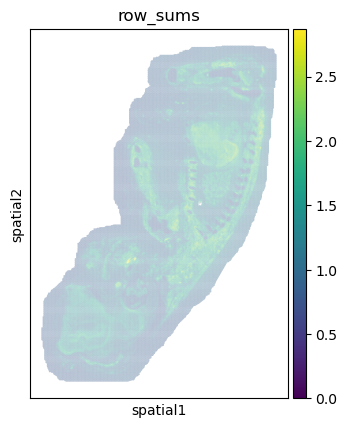

In [9]:
sc.pl.spatial(
    sm_adata,
    color='row_sums',   # replace with the .obs column name
    spot_size=50
)

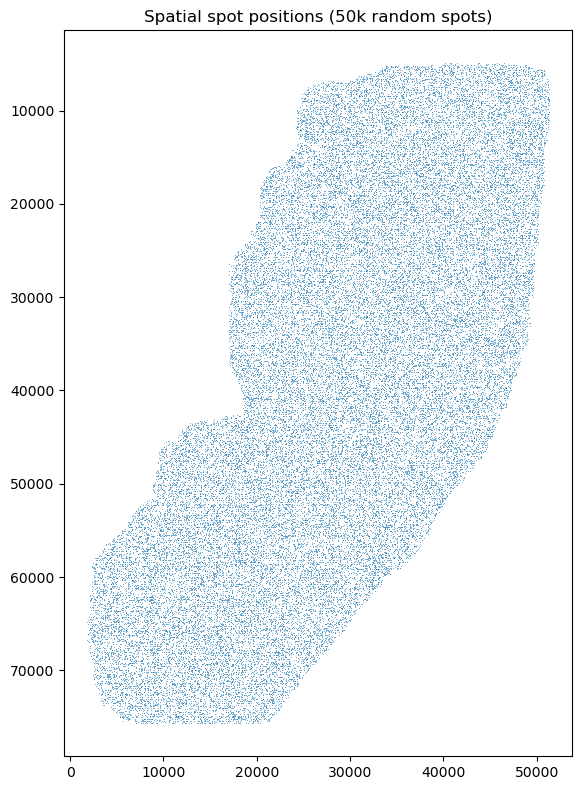

In [4]:
coords = sm_adata.obsm['spatial']

rng = np.random.default_rng(42)
idx = rng.choice(sm_adata.n_obs, size=50_000, replace=False)
x, y = coords[idx, 0], coords[idx, 1]

plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=0.5, linewidths=0, alpha=0.5, rasterized=True)
plt.title("Spatial spot positions (50k random spots)")
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

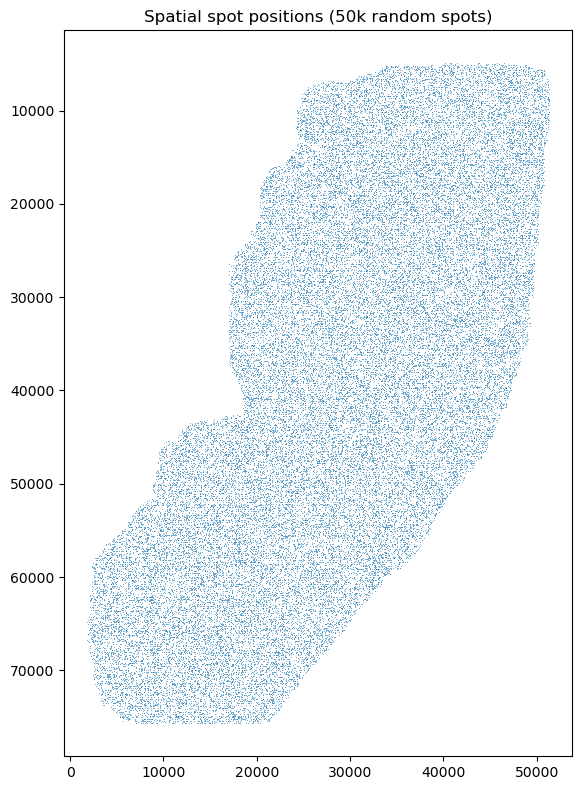

In [4]:
coords = sm_adata.obsm['spatial']

rng = np.random.default_rng(42)
idx = rng.choice(sm_adata.n_obs, size=50_000, replace=False)
x, y = coords[idx, 0], coords[idx, 1]

plt.figure(figsize=(8, 8))
plt.scatter(x, y, s=0.5, linewidths=0, alpha=0.5, rasterized=True)
plt.title("Spatial spot positions (50k random spots)")
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Running network clustering with parameters:
PCC hard cutoff: 0.3, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.4, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.5, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.6, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.7, clustering soft power: 1, 3, 5, 7, 9, 
PCC hard cutoff: 0.8, clustering soft power: 1, 3, 5, 7, 9, 


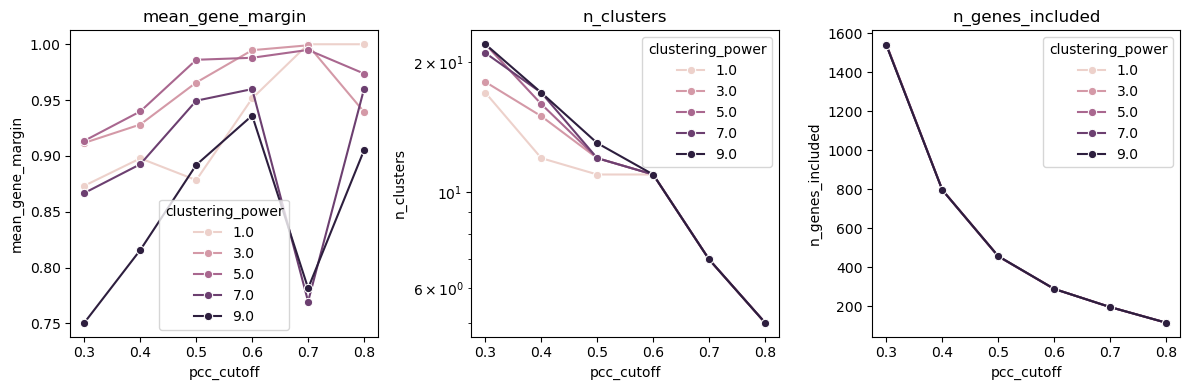

In [8]:
smoothie.select_clustering_params(
    gene_names=sm_adata.var_names,
    pearsonR_mat=pearsonR_mat,
    output_folder=None,
    pcc_cutoffs=[0.3, 0.4, 0.5, 0.6, 0.7, 0.8],
    clustering_powers=[1, 3, 5, 7, 9],
    min_genes_for_module=5
)

In [ ]:
adata = ad.read_h5ad("../data/GSM9629357_CS23_E2S1_bin1_smooth.h5ad")